# minimize() API Example

The `minimize` method is a simpler way to call an optimization framework, but offers limited flexibility over the problem definition.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from boma.benchmarks.registry import get_problem
from boma.frameworks import minimize

## Using EGO with `minimize` (no constraints)

In [2]:
problem = get_problem("Spring")

opt_data, optimizer = minimize(problem.objective[-1],
                    problem.bounds,
                    costs=[1],
                    method="sego",      # even with no constraints, the keyword 'sego' must be used
                    max_iter=10,)

| iter= 0/10 | budget=6.000/inf | f_min=-5.471e-01 | rscv_min=0.000e+00 |
| iter= 1/10 | budget=7.000/inf | f_min=-7.437e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.194 | acq_time=0.302
| iter= 2/10 | budget=8.000/inf | f_min=-7.437e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.277 | acq_time=0.303
| iter= 3/10 | budget=9.000/inf | f_min=-8.768e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.243 | acq_time=0.321
| iter= 4/10 | budget=10.000/inf | f_min=-9.312e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.303 | acq_time=0.316
| iter= 5/10 | budget=11.000/inf | f_min=-9.775e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.247 | acq_time=0.277
| iter= 6/10 | budget=12.000/inf | f_min=-9.979e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.222 | acq_time=0.351
| iter= 7/10 | budget=13.000/inf | f_min=-9.979e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.235 | acq_time=0.269
| iter= 8/10 | budget=14.000/inf | f_min=-9.995e-01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.224 | acq_time=0.182
|

### Plotting EGO result

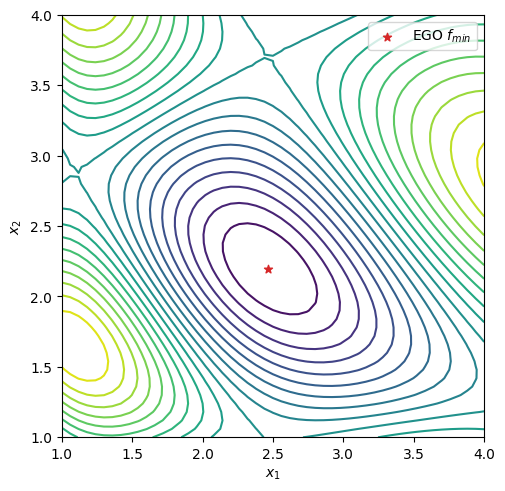

In [3]:
idx = np.argmin(optimizer.yt[-1])
fmin = optimizer.yt[-1][idx]
xmin = optimizer.xt[-1][idx]

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 51)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])

fig, ax = plt.subplots(layout="constrained")

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :]).item()

Z = z.reshape(XX.shape)


ax.contour(XX, YY, Z, levels=20)

ax.scatter(xmin[0], xmin[1], c="C3", marker="*", zorder=10, label=r"EGO $f_{min}$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_aspect("equal")
ax.legend()

plt.show()

## Using SEGO with `minimize` (with constraints)

In [4]:
problem = get_problem("TwoConstraints")

# the minimize() method can only be used with inequality constraints of the form g(x) <= 0.
list_of_constraints = [
    problem.constraints[0][-1],
    problem.constraints[1][-1],
]

opt_data, optimizer = minimize(problem.objective[-1],
                    problem.bounds,
                    costs=[1],
                    method="sego",
                    max_iter=10,
                    constraints=list_of_constraints,
                               )

| iter= 0/10 | budget=6.000/inf | f_min=1.394e+01 | rscv_min=0.000e+00 |
| iter= 1/10 | budget=7.000/inf | f_min=8.825e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.695 | acq_time=0.449
| iter= 2/10 | budget=8.000/inf | f_min=8.825e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.760 | acq_time=1.016
| iter= 3/10 | budget=9.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.821 | acq_time=2.445
| iter= 4/10 | budget=10.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.726 | acq_time=4.270
| iter= 5/10 | budget=11.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.661 | acq_time=2.307
| iter= 6/10 | budget=12.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.641 | acq_time=4.992
| iter= 7/10 | budget=13.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.668 | acq_time=5.163
| iter= 8/10 | budget=14.000/inf | f_min=8.578e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.668 | acq_time=6.241
| iter= 9/

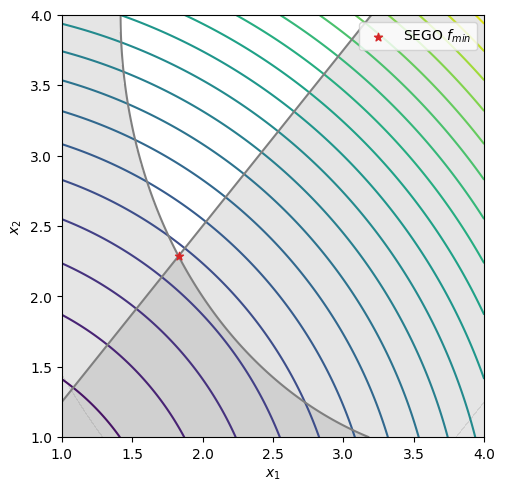

In [5]:
feasible_indices = (optimizer.ct[-1] <= 1e-4).all(axis=1)
idx = np.argmin(optimizer.yt[-1][feasible_indices])
fmin = optimizer.yt[-1][feasible_indices][idx]
xmin = optimizer.xt[-1][feasible_indices][idx]

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = [np.empty(data.shape[0]) for _ in range(problem.num_cstr)]

fig, ax = plt.subplots(layout="constrained")

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :]).item()

    for c_id in range(problem.num_cstr):
        c[c_id][i] = problem.constraints[c_id][-1](data[i, :]).item()

Z = z.reshape(XX.shape)

C = []
for c_id in range(problem.num_cstr):
    C.append(c[c_id].reshape(XX.shape))

ax.contour(XX, YY, Z, levels=20)

for c_id in range(problem.num_cstr):
    ax.contourf(XX, YY, np.where(C[c_id] <= 0, np.nan, C[c_id]), levels=0, colors="C7", alpha=0.20)
    ax.contour(XX, YY, C[c_id], levels=[0], colors="C7")

ax.scatter(xmin[0], xmin[1], c="C3", marker="*", zorder=10, label=r"SEGO $f_{min}$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_aspect("equal")
ax.legend()

plt.show()

## Using MFSEGO with `minimize` (with constraints, with multi-fidelity)

- `optimizer_kwargs` allow some control over the optimizer arguments.
- `strategy_kwargs` allow some control over the acquisition strategy arguments. Allowed arguments depend on the strategy itself.

In [6]:
problem = get_problem("Branin1")

optimizer_kwargs = {
    "results_dir": "mfsego_minimize",
    "max_budget": 15,
}

strategy_kwargs = {
    "n_start": 10,                      # acquisition function multi-start
    "fidelity_crit": "pessimistic",     # fidelity criterion: obj-only, optimistic, pessimistic, average
}

opt_data, optimizer = minimize(problem.objective,
                    problem.bounds,
                    costs=[0.1, 1],
                    method="mfsego",
                    constraints=problem.constraints,
                    optimizer_kwargs=optimizer_kwargs,
                    strategy_kwargs=strategy_kwargs,
                               )

| iter= 0/inf | budget=6.600/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 |
| iter= 1/inf | budget=6.700/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.028 | acq_time=0.348
| iter= 2/inf | budget=6.800/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=0.970 | acq_time=0.461
| iter= 3/inf | budget=6.900/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.109 | acq_time=0.358
| iter= 4/inf | budget=7.000/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.182 | acq_time=0.693
| iter= 5/inf | budget=7.100/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.087 | acq_time=0.918
| iter= 6/inf | budget=7.200/15.000 | f_min=2.073e+01 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.034 | acq_time=0.492
| iter= 7/inf | budget=8.300/15.000 | f_min=5.576e+00 | rscv_min=0.000e+00 | lvl=1/1 | gp_time=0.945 | acq_time=1.107
| iter= 8/inf | budget=8.400/15.000 | f_min=5.576e+00 | rscv_min=0.000e+00 | lvl=0/1 | gp_time=1.

### Plotting MFSEFO result

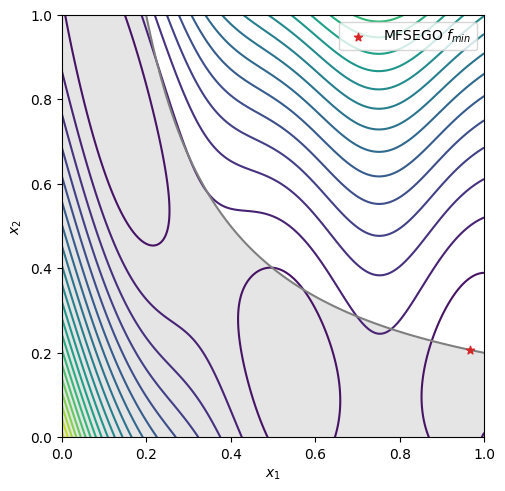

In [7]:
feasible_indices = np.where(optimizer.ct[-1] <= 0)[0]
idx = np.argmin(optimizer.yt[-1][feasible_indices])
fmin = optimizer.yt[-1][feasible_indices][idx]
xmin = optimizer.xt[-1][feasible_indices][idx]

X = np.linspace(problem.bounds[0, 0], problem.bounds[0, 1], 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

fig, ax = plt.subplots(layout="constrained")

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :]).item()
    c[i] = problem.constraints[0][-1](data[i, :]).item()

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(xmin[0], xmin[1], c="C3", marker="*", zorder=10, label="MFSEGO $f_{min}$")

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_aspect("equal")
ax.legend()

plt.show()